In [1]:
#Import essential libraries for data manipulation, visualization,preprocessing, machine learning model training, and evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [2]:
#loading dataset
df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
#displaying number of rows and columns in dataset
df.shape

(32581, 12)

In [4]:
#displaying column names, data types and non_null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
#checking missing values and handle null entries
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
# Removing extra spaces from column names
# Creating binary target variable 'Risk'

df.columns = df.columns.str.strip()

df["Risk"] = df["loan_status"]

df.drop("loan_status", axis=1, inplace=True)

df["Risk"].value_counts()

Risk
0    25473
1     7108
Name: count, dtype: int64

In [7]:
# Remove unwanted automatically generated columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Risk
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3,1
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3,1
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2,1
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4,1


In [8]:
# Fill missing values as follows
# Categorical columns by Mode
#  Numerical columns by Median

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
Risk                          0
dtype: int64

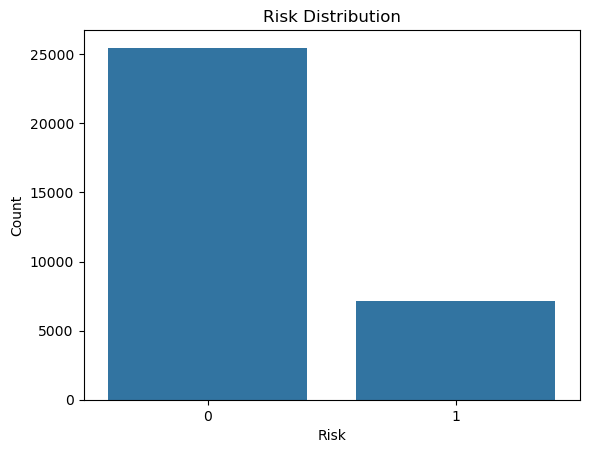

In [9]:
# Visualize class distribution of Risk variable

sns.countplot(x="Risk", data=df)
plt.title("Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

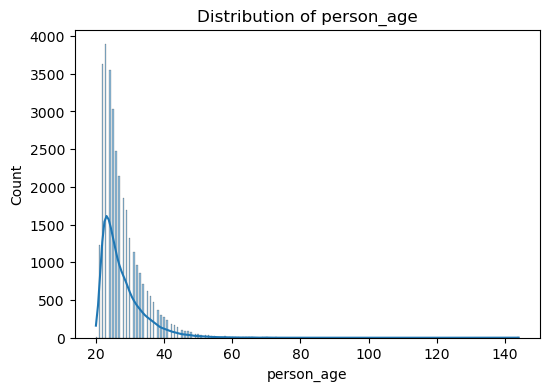

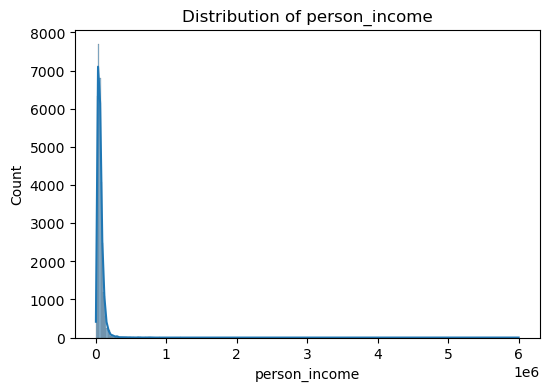

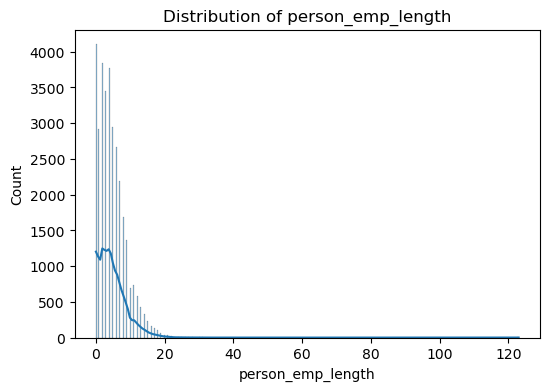

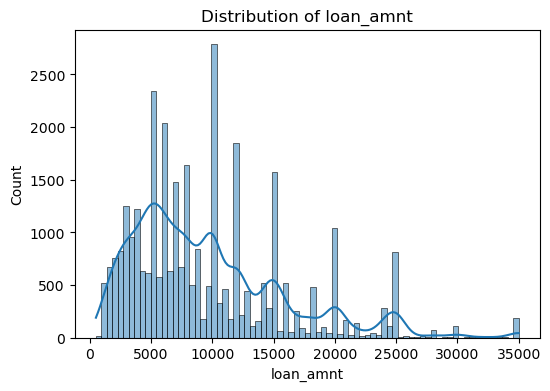

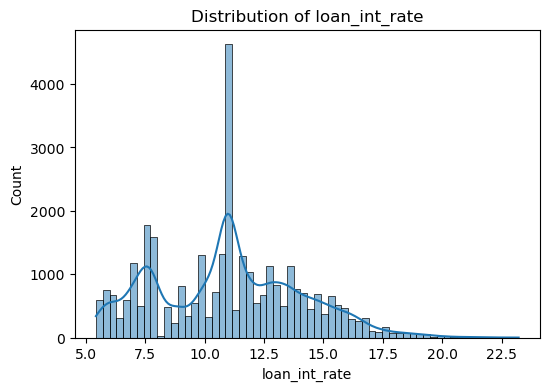

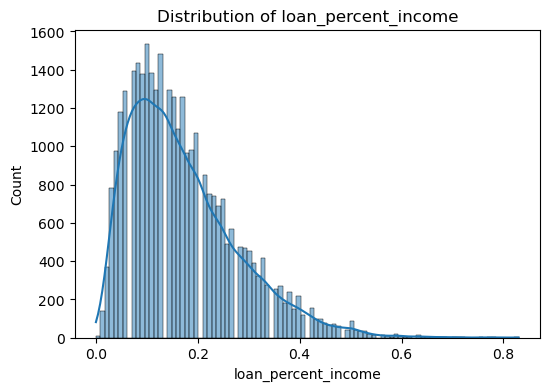

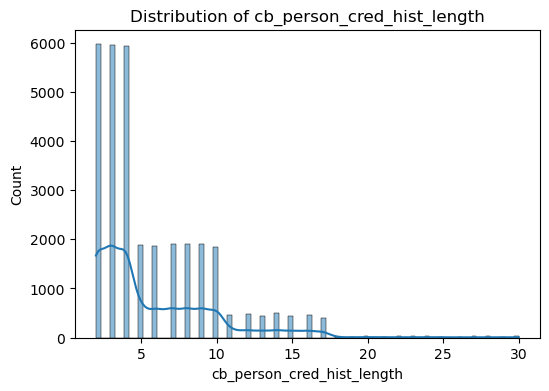

In [10]:
# Plot histograms for all numerical features

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = num_cols.drop("Risk")

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

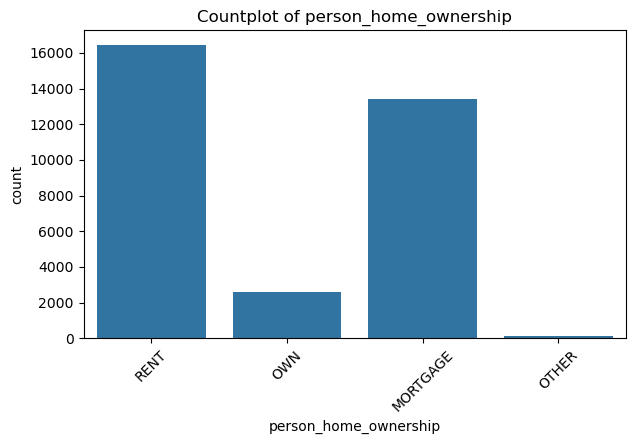

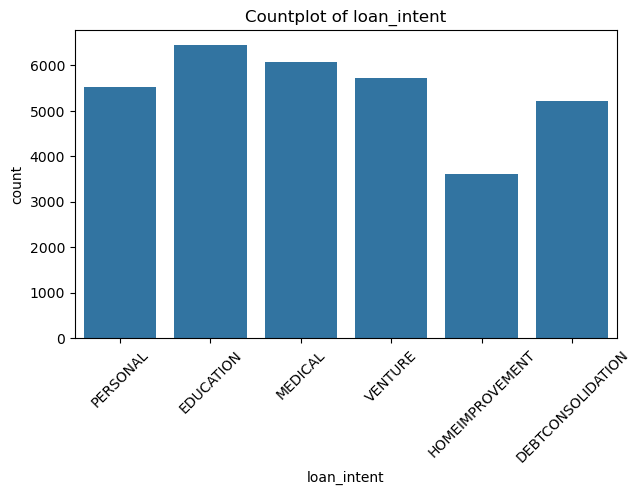

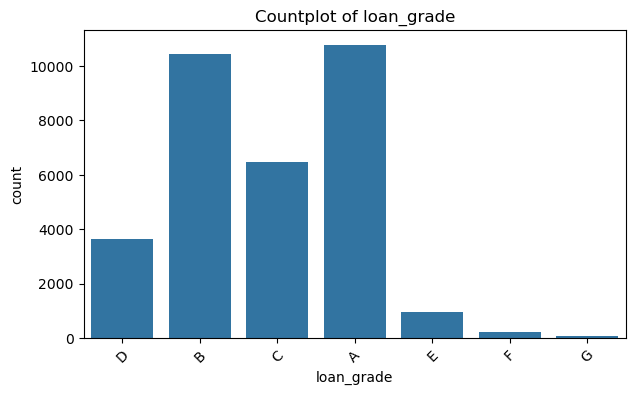

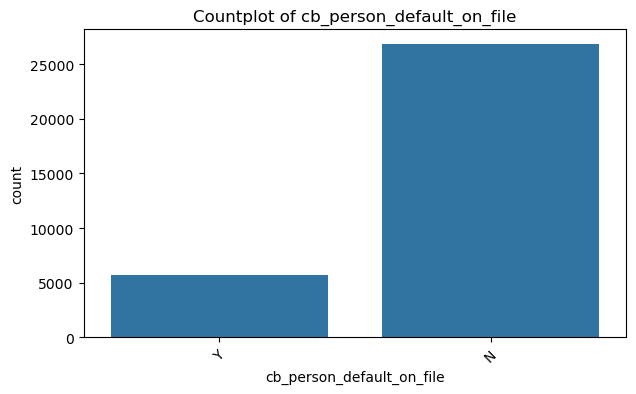

In [11]:
# Visualize frequency distribution of categorical features

cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

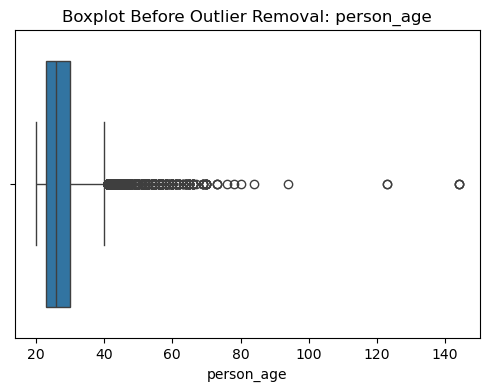

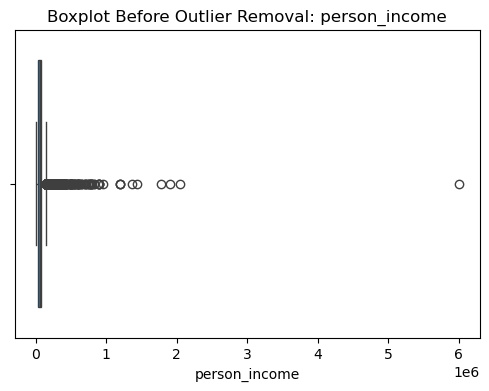

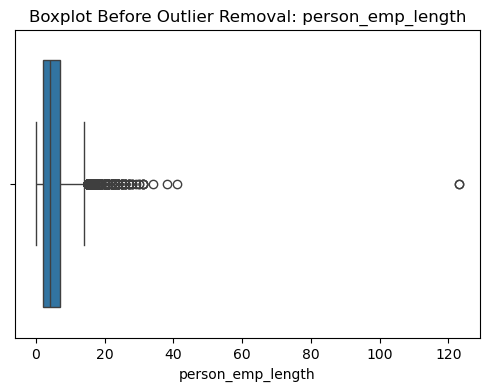

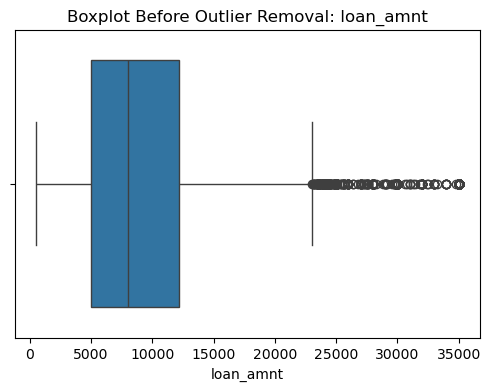

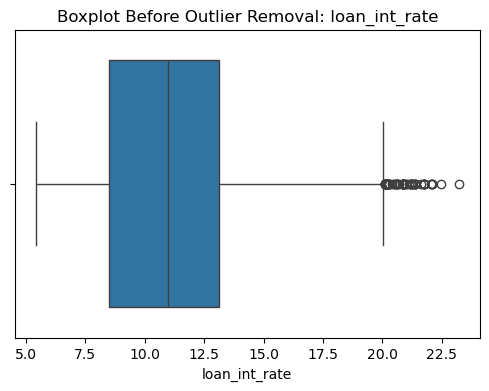

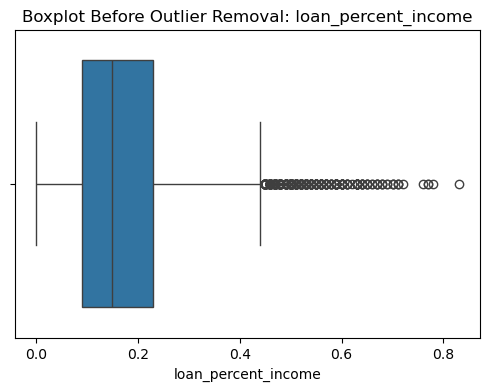

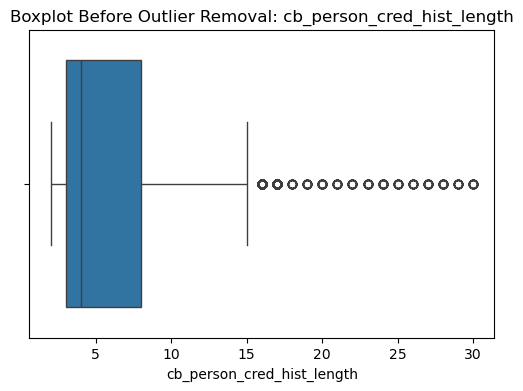

In [12]:
# Detect outliers visually using boxplots

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot Before Outlier Removal: {col}")
    plt.show()

In [13]:
# Remove outliers using IQR method

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

df.shape

(26149, 12)

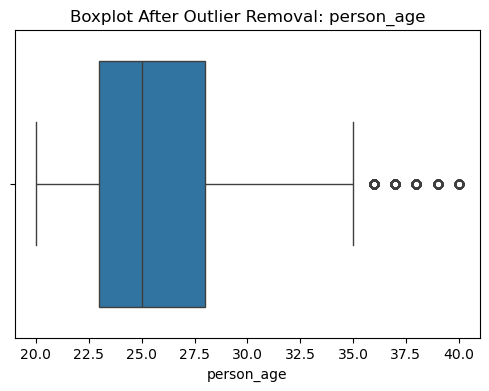

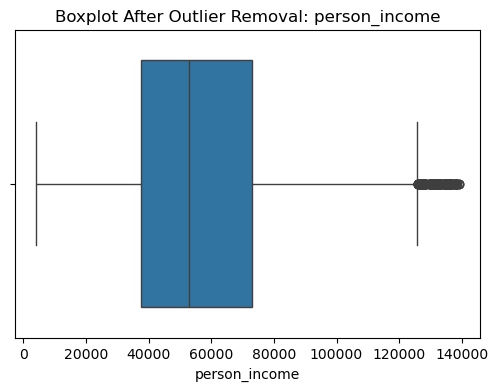

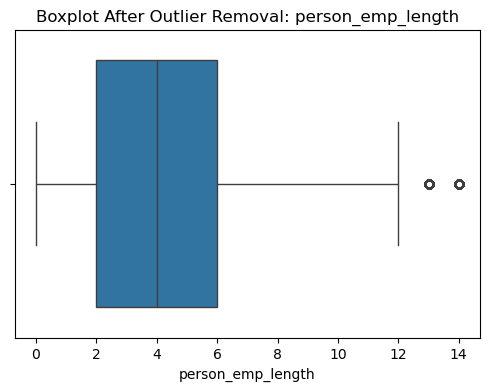

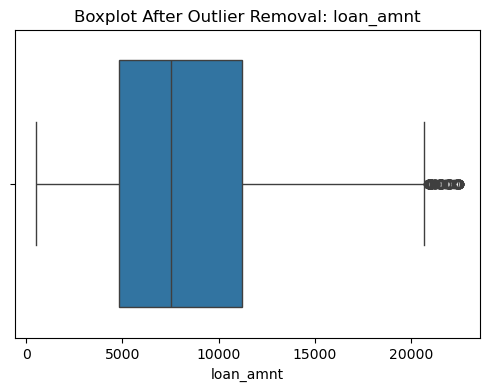

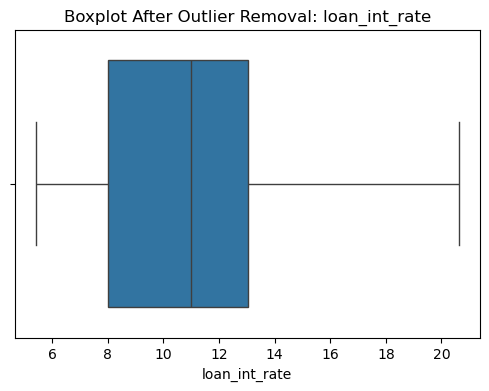

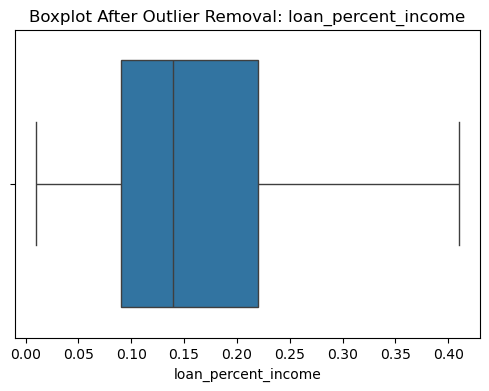

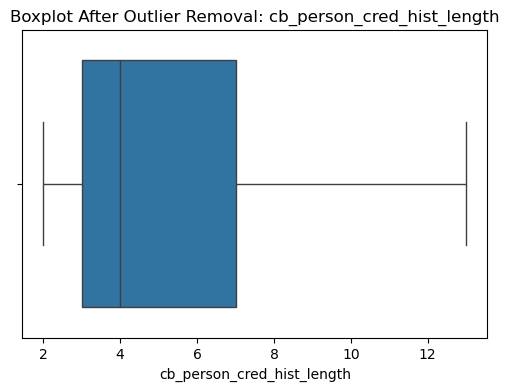

In [15]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = num_cols.drop("Risk")
# Verifying that outliers have been removed

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot After Outlier Removal: {col}")
    plt.show()

# for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Risk", y=col, data=df)
    plt.title(f"{col} vs Risk")
    plt.show()

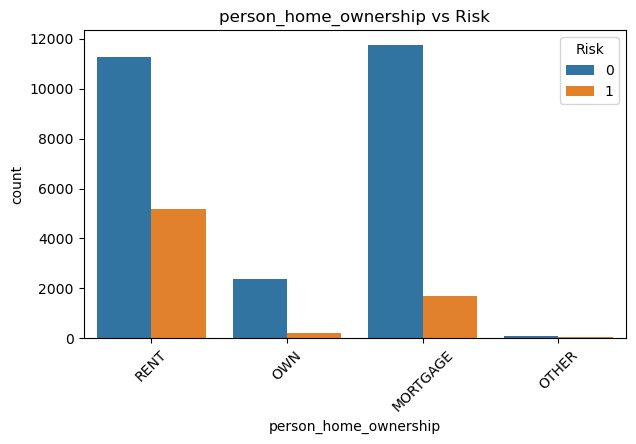

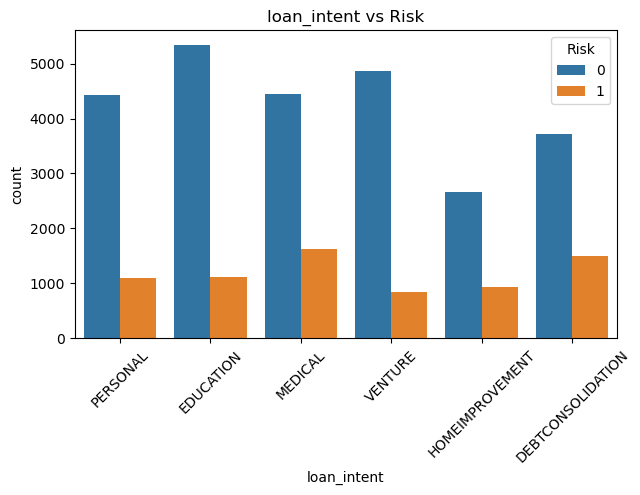

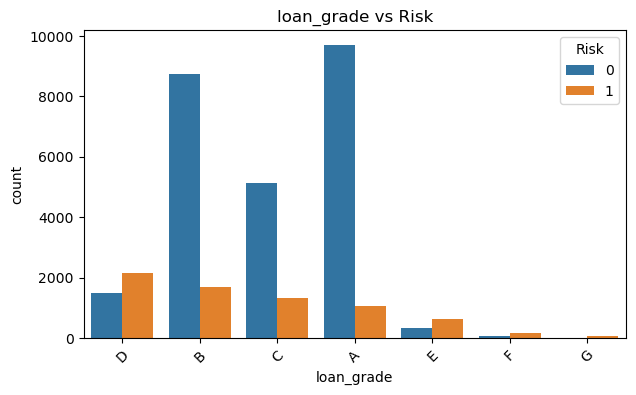

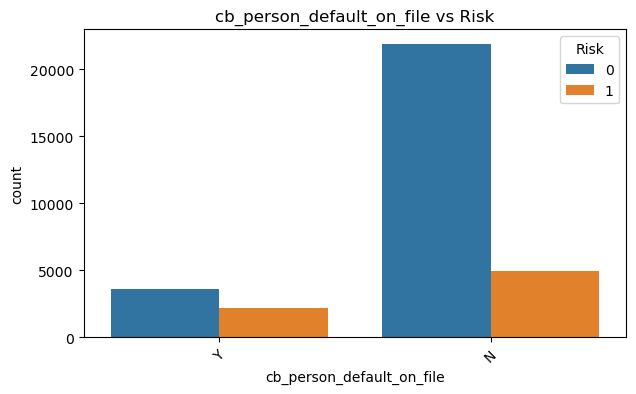

In [13]:
# Visualize impact of categorical features on Risk
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(x=col, hue="Risk", data=df)
    plt.title(f"{col} vs Risk")
    plt.xticks(rotation=45)
    plt.show()

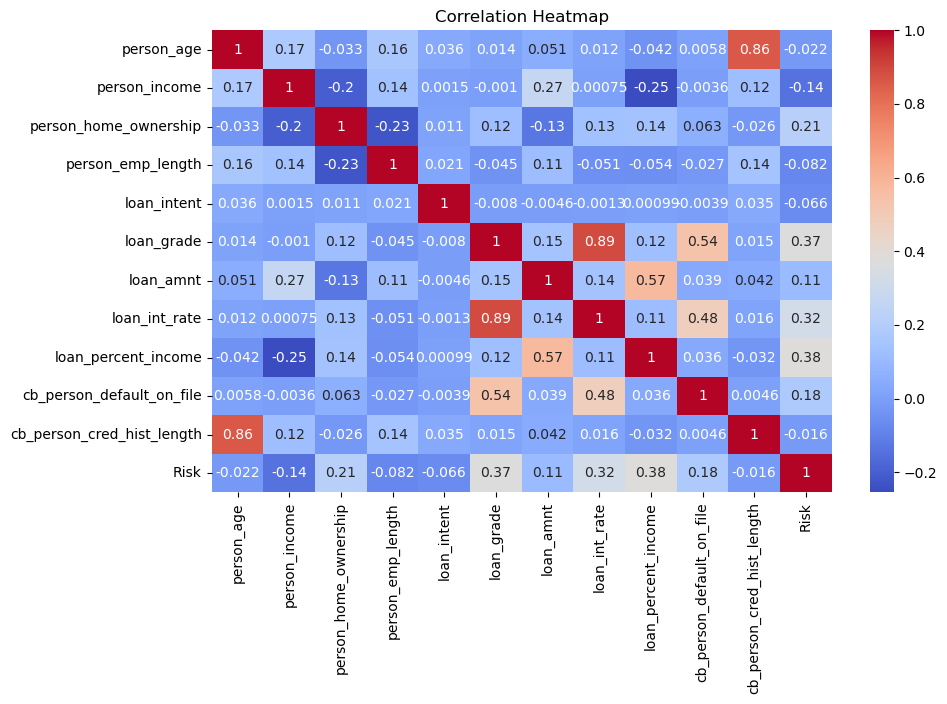

In [14]:
# Encoding categorical features temporarily and generating heatmaps
temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.columns:
    if temp_df[col].dtype == "object":
        temp_df[col] = le.fit_transform(temp_df[col])

plt.figure(figsize=(10, 6))
sns.heatmap(temp_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Convert categorical variables into numerical form

label_encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Risk
0,22,59000,3,123.0,4,3,35000,16.02,0.59,1,3,1
1,21,9600,2,5.0,1,1,1000,11.14,0.10,0,2,0
2,25,9600,0,1.0,3,2,5500,12.87,0.57,0,3,1
3,23,65500,3,4.0,3,2,35000,15.23,0.53,0,2,1
4,24,54400,3,8.0,3,2,35000,14.27,0.55,1,4,1


In [31]:
# Separating features and target
X = df.drop("Risk", axis=1)
y = df["Risk"]
# Spliting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [32]:
# Standardizing numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# Training multiple machine learning models
# Logistic Regression
# Decision Tree
# Random Forest
# Svm
# knn

lr = LogisticRegression(max_iter=1000)

dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=5
)

lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
# Generate predictions and probability scores for all trained models


lr_pred = lr.predict(X_test_scaled)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test_scaled)
knn_pred = knn.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
dt_prob = dt.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]

In [20]:
#evaluating models

def evaluate_model(model_name, y_test, y_pred, y_prob):
    print("Model:", model_name)
    print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
    print("Precision:", round(precision_score(y_test, y_pred), 3))
    print("Recall:", round(recall_score(y_test, y_pred), 3))
    print("F1 Score:", round(f1_score(y_test, y_pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [21]:
# Evaluating Logistic Regression performance
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)

Model: Logistic Regression
Accuracy: 84.54 %
Precision: 0.726
Recall: 0.468
F1 Score: 0.569
ROC-AUC: 0.854

Confusion Matrix:
[[7266  376]
 [1135  998]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      7642
           1       0.73      0.47      0.57      2133

    accuracy                           0.85      9775
   macro avg       0.80      0.71      0.74      9775
weighted avg       0.83      0.85      0.83      9775



In [22]:
# Evaluating Decision Tree performance
evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)

Model: Decision Tree
Accuracy: 90.68 %
Precision: 0.957
Recall: 0.6
F1 Score: 0.738
ROC-AUC: 0.876

Confusion Matrix:
[[7584   58]
 [ 853 1280]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7642
           1       0.96      0.60      0.74      2133

    accuracy                           0.91      9775
   macro avg       0.93      0.80      0.84      9775
weighted avg       0.91      0.91      0.90      9775



In [23]:
# Evaluating Support Vector Machine performance
evaluate_model("Support Vector Machine", y_test, svm_pred, svm_prob)

Model: Support Vector Machine
Accuracy: 88.66 %
Precision: 0.856
Recall: 0.578
F1 Score: 0.69
ROC-AUC: 0.876

Confusion Matrix:
[[7434  208]
 [ 900 1233]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      7642
           1       0.86      0.58      0.69      2133

    accuracy                           0.89      9775
   macro avg       0.87      0.78      0.81      9775
weighted avg       0.88      0.89      0.88      9775



In [24]:
# Evaluating K-Nearest Neighbors performance
evaluate_model("K-Nearest Neighbors", y_test, knn_pred, knn_prob)

Model: K-Nearest Neighbors
Accuracy: 87.32 %
Precision: 0.785
Recall: 0.578
F1 Score: 0.665
ROC-AUC: 0.849

Confusion Matrix:
[[7304  338]
 [ 901 1232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7642
           1       0.78      0.58      0.67      2133

    accuracy                           0.87      9775
   macro avg       0.84      0.77      0.79      9775
weighted avg       0.87      0.87      0.87      9775



In [25]:
# Evaluating Random Forest performance
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

Model: Random Forest
Accuracy: 89.96 %
Precision: 0.916
Recall: 0.595
F1 Score: 0.721
ROC-AUC: 0.898

Confusion Matrix:
[[7525  117]
 [ 864 1269]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7642
           1       0.92      0.59      0.72      2133

    accuracy                           0.90      9775
   macro avg       0.91      0.79      0.83      9775
weighted avg       0.90      0.90      0.89      9775



In [26]:
# Comparing all models using performance metrics
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, knn_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, knn_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, knn_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.845422,0.726346,0.467886,0.569147,0.853906
1,Decision Tree,0.906803,0.956652,0.600094,0.737540,0.876131
2,Random Forest,0.899642,0.915584,0.594937,0.721228,0.898444
3,Support Vector Machine,0.886650,0.855656,0.578059,0.689983,0.875753
4,K-Nearest Neighbors,0.873248,0.784713,0.577590,0.665406,0.849439


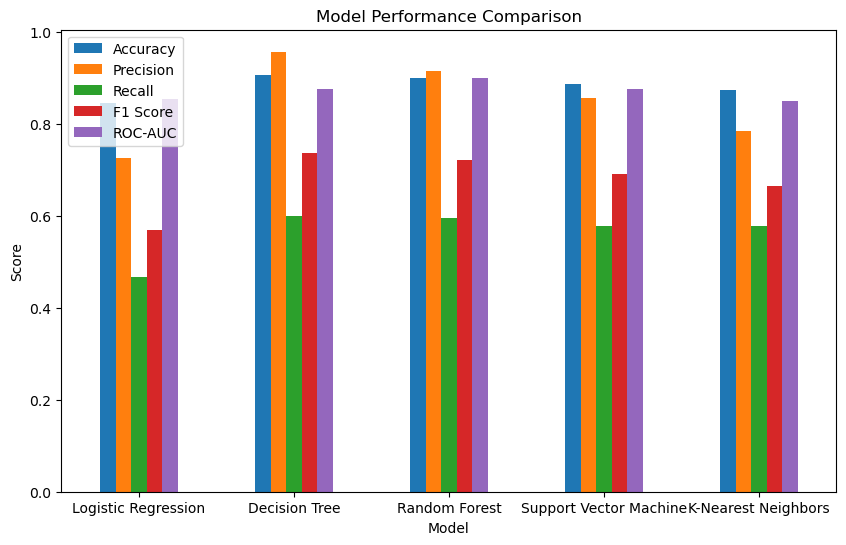

In [28]:
# Ploting a comparison of model metrics
comparison.set_index("Model").plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [29]:
#selecting best model based on evaluation metrics
best_model = rf

print("Random Forest selected as the final model.")

Random Forest selected as the final model.


In [30]:
# Accepting the customer information from user
print("Enter customer details:\n")

user_data = {}

for col in X.columns:
    if col in label_encoders:
        print(f"\nAllowed values for {col}:")
        print(list(label_encoders[col].classes_))

        value = input(f"Enter {col}: ")

        if value in label_encoders[col].classes_:
            user_data[col] = label_encoders[col].transform([value])[0]
        else:
            print("Invalid value. Using most common value.")
            user_data[col] = df[col].mode()[0]
    else:
        user_data[col] = float(input(f"Enter {col}: "))

user_df = pd.DataFrame([user_data])

prediction = best_model.predict(user_df)[0]

if prediction == 1:
    print("\nPredicted Credit Risk: Risky")
else:
    print("\nPredicted Credit Risk: Not Risky")

Enter customer details:



Enter person_age:  28
Enter person_income:  55000



Allowed values for person_home_ownership:
['MORTGAGE', 'OTHER', 'OWN', 'RENT']


Enter person_home_ownership:  RENT
Enter person_emp_length:  4



Allowed values for loan_intent:
['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']


Enter loan_intent:  EDUCATION



Allowed values for loan_grade:
['A', 'B', 'C', 'D', 'E', 'F', 'G']


Enter loan_grade:  B
Enter loan_amnt:  8000
Enter loan_int_rate:  11.5
Enter loan_percent_income:  0.15



Allowed values for cb_person_default_on_file:
['N', 'Y']


Enter cb_person_default_on_file:  N
Enter cb_person_cred_hist_length:  5



Predicted Credit Risk: Not Risky
